# TensorFlow 2 quickstart for beginners

In [22]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.callbacks import TensorBoard
import datetime
import subprocess

In [24]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

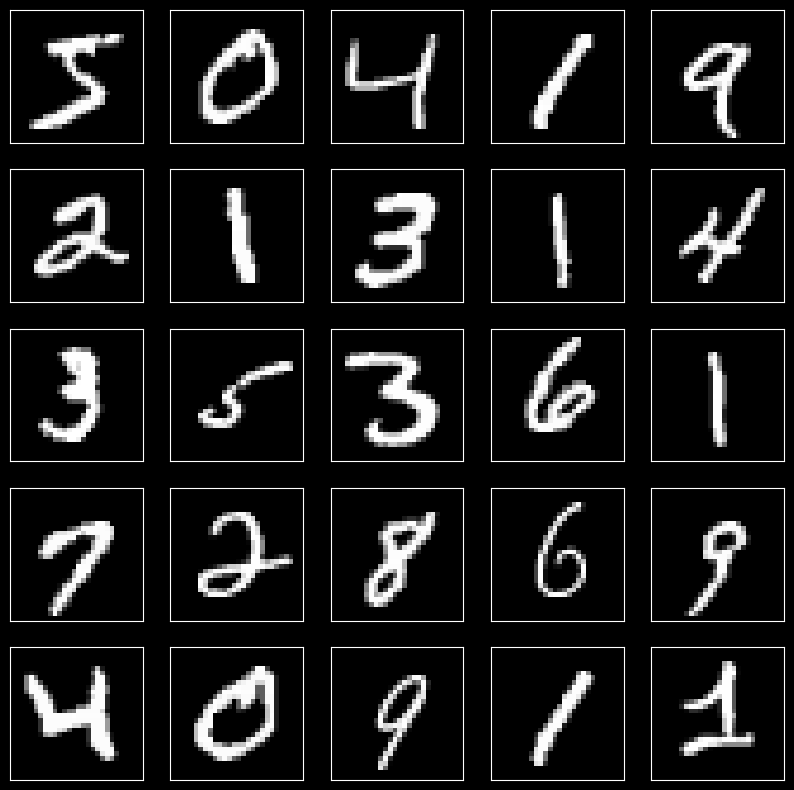

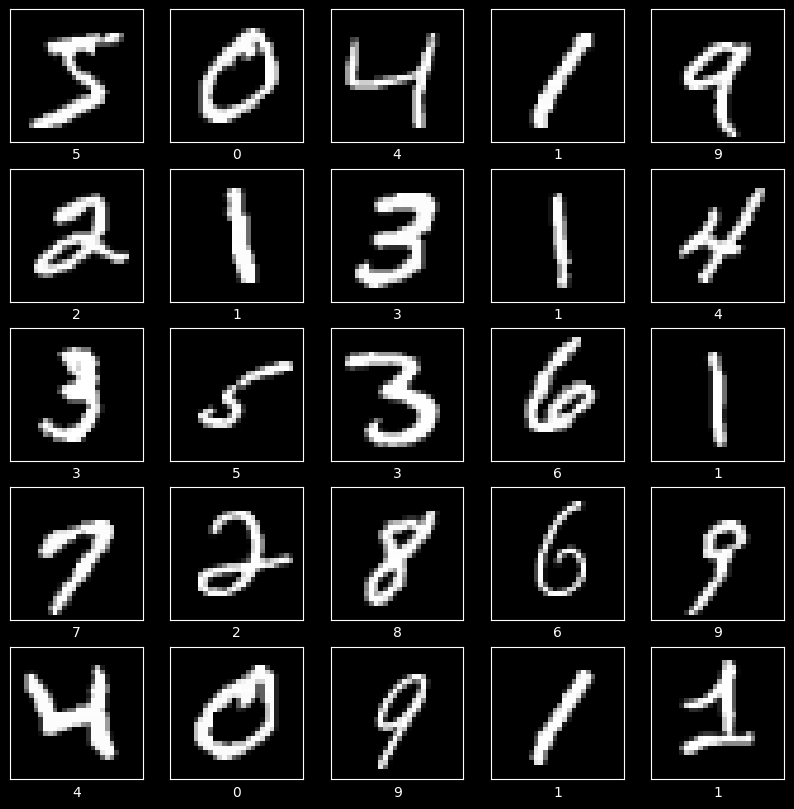

In [25]:
def show_mnist_without_label():
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(x_train[i], cmap="gray")

def show_mnist_with_label():
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(x_train[i], cmap="gray")
        plt.xlabel(y_train[i])

show_mnist_without_label()
show_mnist_with_label()

In [26]:
def create_model(input_shape1, input_shape2, output_shape, activation):
    model = tf.keras.models.Sequential([
      tf.keras.layers.Flatten(input_shape=(input_shape1, input_shape2)),
      tf.keras.layers.Dense(output_shape, activation=activation),
      tf.keras.layers.Dropout(0.4),
      tf.keras.layers.Dense(10)
    ])
    return model

mymodel = create_model(28, 28, 128, 'relu')
mymodel.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
predictions = mymodel(x_train[:1]).numpy()
predictions

array([[-0.22961266, -0.38260406, -0.42819744,  0.3652771 ,  0.34280425,
        -0.8542354 ,  0.2793074 , -0.10866521,  0.18326332,  0.46420592]],
      dtype=float32)

In [28]:
tf.nn.softmax(predictions).numpy()

array([[0.07631591, 0.0654895 , 0.06257067, 0.13834783, 0.13527344,
        0.04086437, 0.12695102, 0.0861275 , 0.11532537, 0.15273432]],
      dtype=float32)

In [29]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [30]:
loss_fn(y_train[:1], predictions).numpy()

3.1974967

In [31]:
mymodel.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

In [32]:
log_dir = "/workspace/logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    update_freq='epoch'
)

In [33]:
history = mymodel.fit(
    x_train,
    y_train,
    epochs=30,
    validation_split=0.25,
    verbose=2,
    callbacks=[tensorboard_callback]
)

Epoch 1/30
1407/1407 - 4s - 3ms/step - accuracy: 0.8846 - loss: 0.3927 - val_accuracy: 0.9485 - val_loss: 0.1786
Epoch 2/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9383 - loss: 0.2111 - val_accuracy: 0.9567 - val_loss: 0.1444
Epoch 3/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9492 - loss: 0.1673 - val_accuracy: 0.9633 - val_loss: 0.1249
Epoch 4/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9569 - loss: 0.1439 - val_accuracy: 0.9657 - val_loss: 0.1171
Epoch 5/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9625 - loss: 0.1261 - val_accuracy: 0.9683 - val_loss: 0.1079
Epoch 6/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9638 - loss: 0.1171 - val_accuracy: 0.9693 - val_loss: 0.1036
Epoch 7/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9676 - loss: 0.1051 - val_accuracy: 0.9729 - val_loss: 0.0939
Epoch 8/30
1407/1407 - 5s - 4ms/step - accuracy: 0.9684 - loss: 0.0991 - val_accuracy: 0.9712 - val_loss: 0.0984
Epoch 9/30
1407/1407 - 3s - 2ms/step - accuracy: 0.9711 - loss: 0.0906 - val_accuracy: 0.9724 - 

In [34]:
mymodel.evaluate(x_test,  y_test, verbose=2)

313/313 - 0s - 762us/step - accuracy: 0.9791 - loss: 0.0884


[0.08844558894634247, 0.9790999889373779]

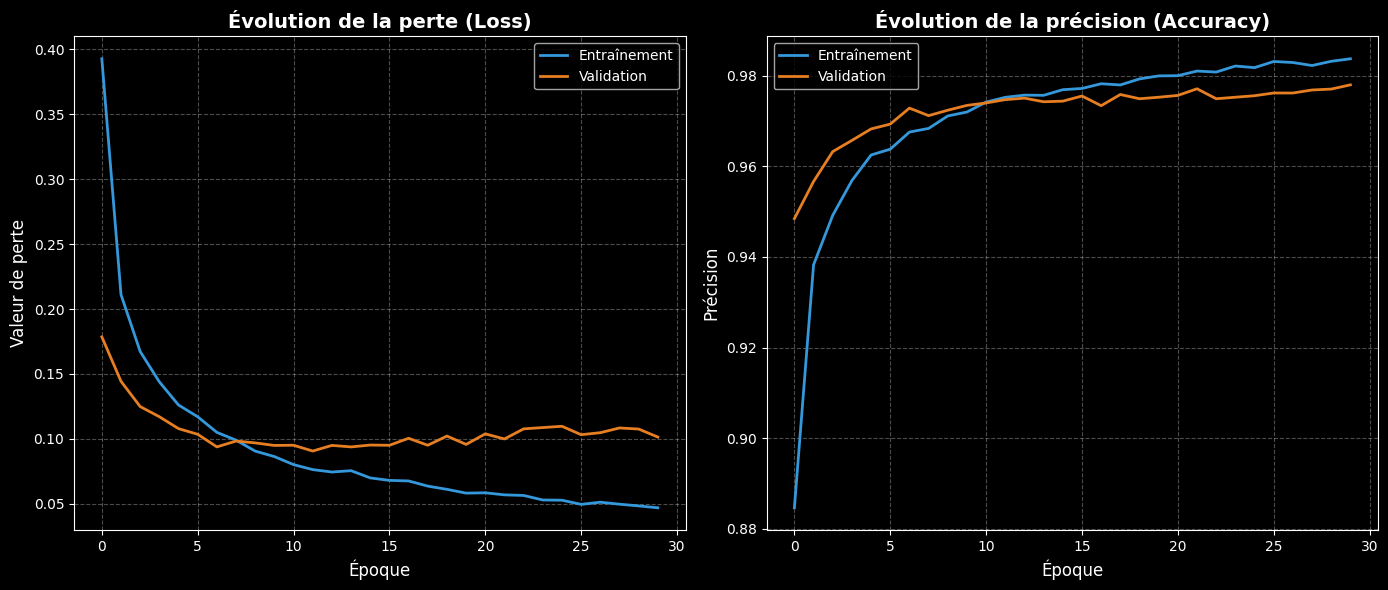

In [35]:
plt.figure(figsize=(14, 6))
plt.style.use('dark_background')

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], color='#3498db', linewidth=2, label='Entraînement')
plt.plot(history.history['val_loss'], color='#e67e22', linewidth=2, label='Validation')
plt.title('Évolution de la perte (Loss)', fontsize=14, fontweight='bold')
plt.ylabel('Valeur de perte', fontsize=12)
plt.xlabel('Époque', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=True, loc='best')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], color='#3498db', linewidth=2, label='Entraînement')
plt.plot(history.history['val_accuracy'], color='#e67e22', linewidth=2, label='Validation')
plt.title('Évolution de la précision (Accuracy)', fontsize=14, fontweight='bold')
plt.ylabel('Précision', fontsize=12)
plt.xlabel('Époque', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=True, loc='best')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=300)  # Sauvegarde haute résolution
plt.show()

In [36]:
print(f"Répertoire actuel : {os.getcwd()}")
os.makedirs('model', exist_ok=True)
mymodel.save(os.path.join('model', 'my_model.keras'))

Répertoire actuel : /tf


In [37]:
print(os.listdir('/tf'))

['model_performance.png', 'projet', '243_26053_29-pycharm-support-libs', 'model', 'requirements.txt']


In [38]:
probability_model = tf.keras.Sequential([
  mymodel,
  tf.keras.layers.Softmax()
])

In [39]:
probability_model(x_test[:5])

<tf.Tensor: shape=(5, 10), dtype=float32, numpy=
array([[2.73591805e-12, 6.40284444e-15, 4.95586697e-11, 1.88187696e-05,
        9.12232147e-21, 8.09236497e-11, 1.22745909e-26, 9.99980330e-01,
        2.06050559e-11, 7.99501265e-07],
       [5.39166857e-20, 2.87044509e-06, 9.99997139e-01, 3.57702548e-11,
        4.37281371e-32, 3.97732113e-15, 2.02277847e-16, 2.11432664e-19,
        1.06472730e-11, 1.06877410e-26],
       [4.49888370e-14, 9.99987364e-01, 2.36672363e-07, 1.85918232e-08,
        5.24221166e-10, 5.23032617e-10, 1.33878020e-10, 6.81486335e-06,
        5.59092314e-06, 1.79478470e-12],
       [9.99973655e-01, 1.99585844e-16, 1.61625417e-06, 9.70557945e-09,
        3.39366357e-09, 1.67431224e-07, 2.44876719e-05, 3.33722205e-09,
        1.90045202e-12, 1.14723484e-07],
       [7.09603043e-10, 2.44157892e-17, 1.06603681e-09, 1.61442193e-14,
        9.99995351e-01, 1.93816832e-13, 3.13023114e-11, 4.63780907e-07,
        2.07477351e-11, 4.13351199e-06]], dtype=float32)>